# 7 - Maximum entropy: a population of structures, not a structure

Every notebook before this one has asked "which structure fits my distances?".
That question has an answer even when it should not. A minimiser will always
return one structure, and it will return one whether the molecule really sits
in one place or shuttles between several. If the molecule exchanges, the
single best-fit structure is not the closed state, not the open state, and
usually not any state the molecule visits: it is the structure whose distances
happen to average to what you measured. It looks like a discovery and it is an
artefact of the question.

The honest question is the one this notebook asks:

> Given a set of candidate structures and a set of FRET distances, **what
> population over those structures is consistent with the data?**

That question has too many answers rather than one. Twenty distances that all
report the same motion do not pin down thirteen populations, however
favourably you count them against each other; whole families of weightings fit
equally well. Something has to choose among them, and the choice is where the
assumptions hide.

**Maximum entropy** makes the choice explicit: among all populations that fit
the data, take the one closest to a stated prior - the flattest one, if the
prior is flat. Any structure the recovered population *does* pick out is
picked out because the data asked for it, not because the regulariser
preferred it. Maximum entropy will not invent a peak. It will very happily
smear one out, which is exactly the failure mode you have to keep in mind when
you read the result.

IMP.bff carries the solver as `IMP.bff.maxent_invert` (and the raw quadratic
form as `IMP.bff.maxent_solve`). It is the same Skilling-Bryan engine that
sits under `MaxEntSpectrum` for lifetime distributions; nothing in it is
specific to decays, which is why it can take a structural ensemble just as
well.

**What runs here is synthetic.** The two structures are real (PDB `6R72` and
`8QOE`, the closed and open states of the transporter BmrA); the ensemble
between them is a cartoon we build ourselves; and the "measurement" is a
mixture we choose, plus noise we draw. That is deliberate - the only way to
say whether a method recovers the truth is to know the truth. Section 6 says
what happens when you do not.

In [1]:
import pathlib
import sys
import tempfile
import time

import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline


def _workshop_dir():
    """doc/workshop, found from whatever directory the kernel was started in."""
    for base in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]:
        for rel in ("", "doc/workshop", "workshop"):
            candidate = base / rel if rel else base
            if (candidate / "workshop.py").is_file():
                return candidate
    raise RuntimeError("workshop.py not found next to this notebook")


sys.path.insert(0, str(_workshop_dir()))
import workshop as ws
import IMP.bff as bff

plt.rcParams.update({"figure.dpi": 110, "font.size": 9, "axes.grid": True,
                     "grid.alpha": 0.25, "axes.spines.top": False,
                     "axes.spines.right": False})

RNG_SEED = 5               # the one noise draw the figures are built on
N_MEMBERS = 13             # ensemble members between the two anchors
SIGMA_E = 0.01             # uncertainty on a species-averaged transfer efficiency
print("IMP.bff", bff.get_module_version(), "| R0 =", ws.R0, "A")

IMP.bff ab5de21 | R0 = 52.0 A


## 1. Two anchors and the ensemble between them

BmrA is a homodimeric ABC transporter, so the interesting coordinate is how
the two protomers sit relative to each other. The workshop helper gives us the
two endpoints as single dimers, chains A and B:

* `closed` - 6R72, nucleotide-binding domains together (X-ray, E504A, ATP/Mg),
* `open` - 8QOE, nucleotide-binding domains apart (cryo-EM).

To get intermediates we do the crudest thing that is still geometrically
meaningful:

1. superimpose the open dimer onto the closed one **using chain A only**, so
   that "what changed" is expressed entirely as a movement of chain B;
2. fit the rigid transform that carries closed-chain-B onto open-chain-B;
3. interpolate that transform - rotate chain B about its own centroid by a
   fraction `t` of the total angle and shift its centroid by the same fraction
   of the total translation - and write out one PDB per `t`.

**What this is not.** The protomers themselves change shape between the two
entries, and we throw that away: every member carries the *closed* internal
conformation of both chains. The printout below quantifies the damage - the
residual after fitting chain B rigidly is of the same order as the motion we
keep. So the ensemble is a one-parameter cartoon of the open/close coordinate,
not a sampled conformational ensemble. For the question "can maximum entropy
recover a population from a distance network?" that is enough, because the
members are distinct and we know their true weights. For a real study you
would put MD frames, normal modes or docked models in here instead, and
nothing downstream would change.

In [2]:
def ca_atoms(pdb_path):
    """{(chain, resi): xyz} for every resolved C-alpha."""
    out = {}
    for line in pathlib.Path(pdb_path).read_text().splitlines():
        if line.startswith("ATOM") and line[12:16].strip() == "CA":
            out[(line[21], int(line[22:26]))] = np.array(
                [float(line[30:38]), float(line[38:46]), float(line[46:54])])
    return out


def kabsch(mobile, target):
    """The rotation and translation that put `mobile` on `target`."""
    mc, tc = mobile.mean(0), target.mean(0)
    u, _, vt = np.linalg.svd((mobile - mc).T @ (target - tc))
    d = np.sign(np.linalg.det(vt.T @ u.T))
    rotation = vt.T @ np.diag([1.0, 1.0, d]) @ u.T
    return rotation, tc - rotation @ mc


def rodrigues(axis, angle):
    k = np.array([[0, -axis[2], axis[1]], [axis[2], 0, -axis[0]], [-axis[1], axis[0], 0]])
    return np.eye(3) + np.sin(angle) * k + (1.0 - np.cos(angle)) * k @ k


def axis_and_angle(rotation):
    angle = np.arccos(np.clip((np.trace(rotation) - 1.0) / 2.0, -1.0, 1.0))
    values, vectors = np.linalg.eig(rotation)
    axis = np.real(vectors[:, np.argmin(np.abs(values - 1.0))])
    axis /= np.linalg.norm(axis)
    if np.linalg.norm(rodrigues(axis, angle) - rotation) > np.linalg.norm(rodrigues(-axis, angle) - rotation):
        axis = -axis
    return axis, angle


closed_pdb, open_pdb = ws.single_dimer("closed"), ws.single_dimer("open")
closed_ca, open_ca = ca_atoms(closed_pdb), ca_atoms(open_pdb)
shared = sorted(set(closed_ca) & set(open_ca))
shared_a = [k for k in shared if k[0] == "A"]
shared_b = [k for k in shared if k[0] == "B"]

rot_a, trans_a = kabsch(np.array([open_ca[k] for k in shared_a]),
                        np.array([closed_ca[k] for k in shared_a]))
open_on_a = {k: rot_a @ v + trans_a for k, v in open_ca.items()}
rmsd_a = np.sqrt((((np.array([open_ca[k] for k in shared_a]) @ rot_a.T + trans_a)
                   - np.array([closed_ca[k] for k in shared_a])) ** 2).sum(1).mean())

b_start = np.array([closed_ca[k] for k in shared_b])
b_end = np.array([open_on_a[k] for k in shared_b])
rot_b, _ = kabsch(b_start, b_end)
axis, angle = axis_and_angle(rot_b)
centroid, shift = b_start.mean(0), b_end.mean(0) - b_start.mean(0)
rmsd_b_rigid = np.sqrt((((b_start - centroid) @ rot_b.T + centroid + shift - b_end) ** 2).sum(1).mean())

print(f"residues shared by both entries : {len(shared)}")
print(f"chain A, open onto closed       : {rmsd_a:5.2f} A rmsd  (the protomer itself changes shape)")
print(f"chain B, rigid-body part        : {np.degrees(angle):5.2f} deg rotation, {np.linalg.norm(shift):5.2f} A translation")
print(f"chain B, what the rigid fit misses: {rmsd_b_rigid:5.2f} A rmsd  (frozen out of the ensemble)")

residues shared by both entries : 1118
chain A, open onto closed       :  8.55 A rmsd  (the protomer itself changes shape)
chain B, rigid-body part        :  7.36 deg rotation, 13.51 A translation
chain B, what the rigid fit misses:  8.70 A rmsd  (frozen out of the ensemble)


In [3]:
# Write one PDB per ensemble member into a scratch directory.
atom_lines = [l for l in pathlib.Path(closed_pdb).read_text().splitlines(keepends=True)
              if l.startswith(("ATOM", "HETATM"))]
is_chain_b = np.array([l[21] == "B" for l in atom_lines])
xyz = np.array([[float(l[30:38]), float(l[38:46]), float(l[46:54])] for l in atom_lines])

ENSEMBLE_DIR = pathlib.Path(tempfile.mkdtemp(prefix="bmra_ensemble_"))
T_GRID = np.linspace(0.0, 1.0, N_MEMBERS)


def place_chain_b(t):
    """Chain B coordinates a fraction `t` of the way from closed to open."""
    moved = xyz.copy()
    moved[is_chain_b] = ((xyz[is_chain_b] - centroid) @ rodrigues(axis, t * angle).T
                         + centroid + t * shift)
    return moved


def write_member(t, chain_b_label="B", extra=None, name=None):
    path = ENSEMBLE_DIR / (name or f"member_t{t:.3f}.pdb")
    with open(path, "w") as handle:
        for line, position in zip(atom_lines, place_chain_b(t)):
            label = chain_b_label if line[21] == "B" else line[21]
            handle.write(line[:21] + label + line[22:30]
                         + "%8.3f%8.3f%8.3f" % tuple(position) + line[54:])
        if extra:
            handle.write(extra)
        handle.write("END\n")
    return path


member_paths = [write_member(t) for t in T_GRID]
print(f"{len(member_paths)} members written to {ENSEMBLE_DIR}")
print("t =", np.round(T_GRID, 3))

13 members written to /var/folders/cl/txwq_hq52rl_t0f9xjk3g5c00000gn/T/bmra_ensemble_0qqahbap
t = [0.    0.083 0.167 0.25  0.333 0.417 0.5   0.583 0.667 0.75  0.833 0.917
 1.   ]


### The swing, in three dimensions

Chain A is the same in every panel; chain B is drawn twice, at `t = 0` (the
closed placement, chain B) and at `t = 1` (the open placement, relabelled
chain C). The two translucent blobs are accessible volumes: the donor at
A542 and the acceptor at B522 - one of the pairs the network below uses. The
volumes, not the C-betas, are what a FRET distance is computed from.

The viewer needs internet access from your browser. If it cannot load, nothing
else in this notebook is affected.

In [4]:
merged = []
for line, position in zip(atom_lines, place_chain_b(1.0)):
    if line[21] == "B":
        merged.append(line[:21] + "C" + line[22:30] + "%8.3f%8.3f%8.3f" % tuple(position) + line[54:])
view_path = write_member(0.0, extra="".join(merged), name="two_states.pdb")

# The volumes come from the member files, not from the merged one: in the merged
# file the two placements of chain B would shadow each other and shrink both clouds.
donor_closed = ws.av(member_paths[0], "A", 542, "Alexa488")
donor_open = ws.av(member_paths[-1], "A", 542, "Alexa488")
acceptor_closed = ws.av(member_paths[0], "B", 522, "Alexa647")
acceptor_open = ws.av(member_paths[-1], "B", 522, "Alexa647")
print(f"<R_DA>_E  A542-B522, t = 0 : {ws.rda_e(donor_closed, acceptor_closed):.1f} A")
print(f"<R_DA>_E  A542-B522, t = 1 : {ws.rda_e(donor_open, acceptor_open):.1f} A")
print("the donor volume is drawn at t = 0; it moves very little, the acceptor does not")

ws.show([{ "title": "BmrA: chain A (grey), chain B closed and chain B open, with two dye volumes",
           "structure": ws.protein_for_view(view_path),
           "clouds": [
               {"pdb": ws.av_pdb(donor_closed, max_points=900), "colour": ws.DONOR_COLOUR, "label": "A542"},
               {"pdb": ws.av_pdb(acceptor_closed, max_points=900), "colour": ws.ACCEPTOR_COLOUR, "label": "B522 at t = 0"},
               {"pdb": ws.av_pdb(acceptor_open, max_points=900), "colour": 0xE8A33D, "label": "B522 at t = 1"},
           ]}], height=480)

<R_DA>_E  A542-B522, t = 0 : 48.7 A
<R_DA>_E  A542-B522, t = 1 : 59.9 A
the donor volume is drawn at t = 0; it moves very little, the acceptor does not


## 2. What each member predicts

For every member we compute an accessible volume at each labelling site and
turn each donor/acceptor pair into `<R_DA>_E` - the distance that reproduces
the mean transfer efficiency of the two clouds, which is what an experiment
reports. The observable we will actually invert is the transfer efficiency
itself,

$$E_k(\text{pair}) = \frac{1}{1 + (\langle R_{DA}\rangle_E / R_0)^6}$$

for member $k$, because efficiency is what a *mixture* averages linearly:

$$E^{\text{obs}}(\text{pair}) = \sum_k w_k \, E_k(\text{pair}).$$

That linearity is the whole reason this problem is a linear inversion and not
a search. Mean distances do **not** average like that - a 60/40 mixture of a
40 A and a 70 A state does not report 52 A - so a network of `<R_DA>_E` values
must be converted to efficiencies before anything is averaged. Getting this
backwards is one of the commoner ways to produce a confident wrong ensemble.

Sites: twenty positions, mostly on the nucleotide-binding domains (they move)
and a few in the transmembrane region (they barely do). Each is used as a
donor on chain A and as an acceptor on chain B, giving 400 candidate pairs
for free once the volumes exist.

In [5]:
SITES = [519, 522, 523, 526, 542, 459, 463, 337, 340, 363,
         402, 450, 446, 336, 62, 161, 231, 322, 353, 175]

start = time.time()
rda_e = np.zeros((len(SITES), len(SITES), N_MEMBERS))
for m, path in enumerate(member_paths):
    donors = {s: ws.av(path, "A", s, "Alexa488") for s in SITES}
    acceptors = {s: ws.av(path, "B", s, "Alexa647") for s in SITES}
    for i, a in enumerate(SITES):
        for j, b in enumerate(SITES):
            rda_e[i, j, m] = ws.rda_e(donors[a], acceptors[b])
efficiency = 1.0 / (1.0 + (rda_e / ws.R0) ** 6)
print(f"{len(SITES) * len(SITES)} candidate pairs x {N_MEMBERS} members "
      f"in {time.time() - start:.1f} s "
      f"({2 * len(SITES) * N_MEMBERS} accessible volumes)")

400 candidate pairs x 13 members in 13.2 s (520 accessible volumes)


### Choosing a network

A pair is worth measuring only if its efficiency stays in the range an
experiment can read - roughly 0.05 to 0.95, outside which the sixth power
flattens everything - and only if it *changes* across the ensemble. We take
the twenty pairs with the largest span in `E`, allowing each site to appear at
most three times so the network does not collapse onto one loop.

The printed table is worth reading before the fit. The best pair moves by
about 0.3 in efficiency across the whole open/close transition. That number
sets the ceiling on everything that follows: with a measurement uncertainty of
0.01 you have roughly thirty resolvable steps along the coordinate *if* the
pairs were independent, and they are not - they all report the same rigid-body
motion.

The left panel of the figure shows why that matters. Every curve is close to a
straight line, and the lines are close to parallel. A design matrix made of
nearly parallel columns is a nearly singular one: a mixture of two members
then predicts almost exactly what the single member halfway between them
predicts, and no amount of solver sophistication can separate the two. Curved,
crossing curves - pairs whose distance passes through $R_0$ in different
places, or moves in opposite directions - are what buys resolution. One pair
here does move the other way (A231-B231); with twenty that did, this notebook
would end on a much happier note.

In [6]:
def build_network(n_pairs=20, e_low=0.06, e_high=0.94, max_uses=3):
    ranked = []
    for i, a in enumerate(SITES):
        for j, b in enumerate(SITES):
            e = efficiency[i, j]
            if e.min() > e_low and e.max() < e_high:
                ranked.append((e.max() - e.min(), a, b, i, j))
    ranked.sort(reverse=True)
    used_a, used_b, network = {}, {}, []
    for span, a, b, i, j in ranked:
        if used_a.get(a, 0) >= max_uses or used_b.get(b, 0) >= max_uses:
            continue
        used_a[a] = used_a.get(a, 0) + 1
        used_b[b] = used_b.get(b, 0) + 1
        network.append((a, b, i, j))
        if len(network) == n_pairs:
            break
    return network


NETWORK = build_network()
design = np.array([efficiency[i, j] for _, _, i, j in NETWORK])   # (pairs, members)
distances = np.array([rda_e[i, j] for _, _, i, j in NETWORK])

print(f"{len(NETWORK)} pairs  |  {'pair':>12}  {'R(t=0)':>7} {'R(t=1)':>7}   {'E(t=0)':>6} {'E(t=1)':>6} {'span':>5}")
for (a, b, _, _), r, e in zip(NETWORK, distances, design):
    print(f"{'':>20}  {'A%d-B%d' % (a, b):>12}  {r[0]:7.1f} {r[-1]:7.1f}   "
          f"{e[0]:6.2f} {e[-1]:6.2f} {e.max() - e.min():5.2f}")
print(f"\nmedian span in E: {np.median(design.max(1) - design.min(1)):.3f}")

20 pairs  |          pair   R(t=0)  R(t=1)   E(t=0) E(t=1)  span
                         A542-B522     48.7    59.9     0.60   0.30  0.30
                         A231-B231     58.7    47.9     0.33   0.62  0.29
                         A522-B542     48.8    59.8     0.59   0.30  0.29
                         A363-B519     50.4    62.0     0.55   0.26  0.29
                         A522-B522     51.2    63.2     0.52   0.24  0.29
                         A542-B519     47.5    57.8     0.63   0.35  0.29
                         A363-B459     46.3    56.4     0.67   0.38  0.29
                         A519-B363     51.2    62.8     0.52   0.24  0.28
                         A519-B542     48.4    58.6     0.61   0.33  0.28
                         A542-B542     47.1    56.8     0.64   0.37  0.27
                         A522-B519     50.6    61.5     0.54   0.27  0.27
                         A519-B522     51.3    62.3     0.52   0.25  0.27
                         A459-B363     46.8    

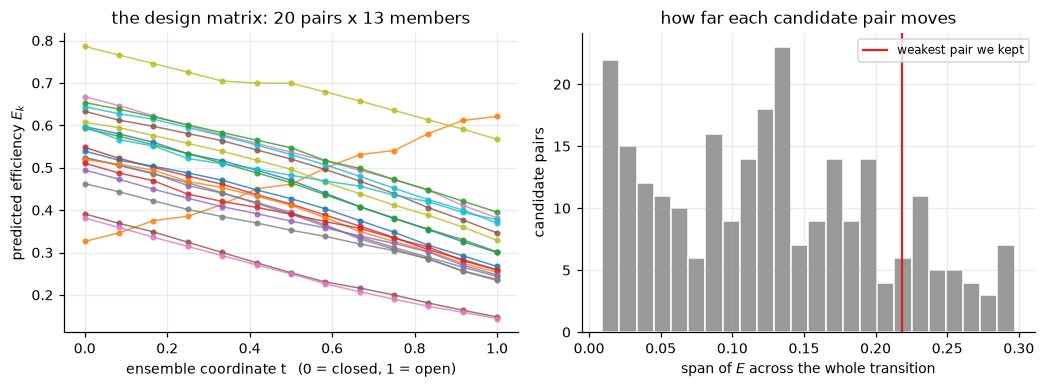

candidate pairs in a readable efficiency range : 254
of those, pairs whose E moves by less than 0.05: 56


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(9.6, 3.6))
for row, (a, b, _, _) in zip(design, NETWORK):
    axes[0].plot(T_GRID, row, marker=".", lw=1, alpha=0.8)
axes[0].set_xlabel("ensemble coordinate t   (0 = closed, 1 = open)")
axes[0].set_ylabel("predicted efficiency $E_k$")
axes[0].set_title(f"the design matrix: {len(NETWORK)} pairs x {N_MEMBERS} members")

blind = []
for i, a in enumerate(SITES):
    for j, b in enumerate(SITES):
        e = efficiency[i, j]
        if e.min() > 0.06 and e.max() < 0.94:
            blind.append(e.max() - e.min())
axes[1].hist(blind, bins=24, color="0.6", edgecolor="white")
axes[1].axvline((design.max(1) - design.min(1)).min(), color="C3", lw=1.5,
                label="weakest pair we kept")
axes[1].set_xlabel("span of $E$ across the whole transition")
axes[1].set_ylabel("candidate pairs")
axes[1].set_title("how far each candidate pair moves")
axes[1].legend(fontsize=8)
fig.tight_layout()
plt.show()

print(f"candidate pairs in a readable efficiency range : {len(blind)}")
print(f"of those, pairs whose E moves by less than 0.05: {sum(1 for s in blind if s < 0.05)}")

## 3. A synthetic measurement

Now we invent the answer so that we can check the method against it.

The truth is a **two-state mixture**: 60 % of the molecules in a
nearly-closed member (`t = 1/6`) and 40 % in a nearly-open one (`t = 5/6`).
That is the physically interesting case and the one a single-structure fit
gets wrong: the average of those two states is not either of them.

The measurement is `E` for each of the twenty pairs, plus Gaussian noise with
`sigma = 0.01`. A word on that number: 0.01 on a species-averaged transfer
efficiency is *good* data - a careful multiparameter experiment with a
well-determined correction factor set. Many published values carry two to
three times that. Section 6 shows what the extra factor of three costs, and it
costs more than you would guess.

Everything from here on uses only `measured`, `SIGMA_E` and `design`. The true
weights are put aside and only brought back to score the answer.

In [8]:
w_true = np.zeros(N_MEMBERS)
w_true[2] = 0.60          # t = 1/6, nearly closed
w_true[10] = 0.40         # t = 5/6, nearly open

rng = np.random.default_rng(RNG_SEED)
noiseless = design @ w_true
measured = noiseless + rng.normal(0.0, SIGMA_E, len(NETWORK))

print(f"{'pair':>12} {'E(closed)':>10} {'E(open)':>9} {'E(mixture)':>11} {'E(measured)':>12}")
for (a, b, _, _), e, truth, obs in zip(NETWORK, design, noiseless, measured):
    print(f"{'A%d-B%d' % (a, b):>12} {e[0]:10.3f} {e[-1]:9.3f} {truth:11.3f} {obs:12.3f}")

chi2_truth = float(((noiseless - measured) ** 2).sum()) / SIGMA_E ** 2 / len(NETWORK)
print(f"\nchi2 per pair at the true weights: {chi2_truth:.2f}  (should scatter around 1)")

        pair  E(closed)   E(open)  E(mixture)  E(measured)
   A542-B522      0.597     0.300       0.478        0.470
   A231-B231      0.326     0.621       0.457        0.444
   A522-B542      0.593     0.301       0.475        0.472
   A363-B519      0.548     0.259       0.423        0.428
   A522-B522      0.524     0.237       0.406        0.417
   A542-B519      0.633     0.346       0.521        0.522
   A363-B459      0.668     0.382       0.552        0.547
   A519-B363      0.524     0.244       0.407        0.399
   A519-B542      0.607     0.329       0.501        0.508
   A542-B542      0.644     0.369       0.539        0.555
   A522-B519      0.540     0.267       0.429        0.432
   A519-B522      0.519     0.253       0.418        0.406
   A459-B363      0.654     0.395       0.551        0.542
   A459-B340      0.511     0.259       0.407        0.423
   A340-B459      0.495     0.247       0.390        0.392
   A363-B523      0.391     0.148       0.281        0.2

## 4. The inversion

`IMP.bff.maxent_invert` minimises

$$Q(x) \;=\; \sum_i w_i \,(Ax - b)_i^2 \;-\; \nu^2 S(x;\,m), \qquad x \ge 0,$$

with $S$ the Skilling-Bryan entropy relative to the prior $m$, which peaks
where $x = m$. So the first term is the fit and the second pulls the answer
towards the prior; `nu` sets the exchange rate between them, and note that it
enters **squared** - doubling `nu` quadruples the pull.

The pieces map onto our problem directly:

| argument | here |
|---|---|
| `design` | the (pairs x members) matrix of predicted efficiencies, row-major |
| `measurements` | the measured efficiencies |
| `weights` | `1/sigma^2` per row |
| `prior` | flat, `1/N` per member - "no member is favoured" |
| `nu` | the regularisation weight |
| `n_rows`, `n_cols` | the shape, passed explicitly because the matrix arrives flat |

One thing the solver does not know is that weights are a population and must
sum to one. It only enforces `x >= 0`. We add the constraint as an extra row
of ones with measurement 1 and a very small uncertainty, which is the usual
trick: a constraint is a measurement you are very sure of. Making that
uncertainty far *too* small is a real way to break the solve - the row then
dominates the normal equations and the iteration stalls - so we use 1e-3,
tight compared to `SIGMA_E` and not absurd.

`MaxEntSolution` carries more than the amplitudes: `chisq` (the weighted sum
of squares, including our constraint row), `entropy`, `objective`,
`iterations`, `gradient_angle`, and two flags that are easy to confuse.
`success` only says the routine ran; a solve that exhausted `max_iter` is
still a success. `converged` is the actual stopping test, `gradient_angle <=
tol`. At small `nu` the entropy gradient is tiny and that angle test can fail
to trigger at all - you will see `converged = False` with the full iteration
count below, and the amplitudes are still perfectly usable. Report both, and
never read `success` as "it worked".

In [9]:
help(bff.maxent_invert)

Help on function maxent_invert in module IMP.bff:

maxent_invert(design, measurements, weights, prior, nu, n_rows, n_cols, max_iter=500, tol=1e-08)
    maxent_invert(DistBase design, DistBase measurements, DistBase weights, DistBase prior, double nu, int n_rows, int n_cols, int max_iter=500, double tol=1e-8) -> MaxEntSolution



In [10]:
def maxent_weights(design, measured, sigma, nu, prior=None,
                   sum_to_one_sigma=1e-3, max_iter=20000, tol=1e-8):
    """Populations over the ensemble members, by maximum entropy.

    Returns the amplitudes, the chi-square per measured pair, the entropy and
    the raw MaxEntSolution so the convergence flags stay visible.
    """
    n_rows, n_members = design.shape
    sigma = np.broadcast_to(np.asarray(sigma, float), (n_rows,))
    a = np.vstack([design, np.ones(n_members)])                  # + the normalisation row
    b = np.append(np.asarray(measured, float), 1.0)
    weights = np.append(1.0 / sigma ** 2, 1.0 / sum_to_one_sigma ** 2)
    prior = np.full(n_members, 1.0 / n_members) if prior is None else np.asarray(prior, float)

    solution = bff.maxent_invert(a.ravel().tolist(), b.tolist(), weights.tolist(),
                                 prior.tolist(), float(nu), a.shape[0], a.shape[1],
                                 int(max_iter), float(tol))
    x = np.asarray(solution.get_amplitudes())
    residual = design @ x - measured
    chi2 = float(residual @ (residual / sigma ** 2)) / n_rows
    entropy = float(np.sum((1.0 - np.log(np.maximum(x, 1e-300) / prior)) * x) - prior.sum())
    return x, chi2, entropy, solution


NU = 0.5
w_maxent, chi2_maxent, entropy_maxent, solution = maxent_weights(design, measured, SIGMA_E, NU)

print(f"nu                 : {NU}")
print(f"sum of weights     : {w_maxent.sum():.4f}")
print(f"chi2 per pair      : {chi2_maxent:.3f}   (true weights give {chi2_truth:.2f})")
print(f"entropy            : {entropy_maxent:.3f}")
print(f"iterations         : {solution.iterations}")
print(f"success / converged: {solution.success} / {solution.converged}  "
      f"(gradient angle {solution.gradient_angle:.2e})")
print()
print(f"{'t':>6} {'true':>7} {'maxent':>8}")
for t, wt, wm in zip(T_GRID, w_true, w_maxent):
    bar = "#" * int(round(40 * wm))
    print(f"{t:6.3f} {wt:7.2f} {wm:8.3f}  {bar}")

nu                 : 0.5
sum of weights     : 0.9999
chi2 per pair      : 0.797   (true weights give 0.91)
entropy            : -0.781
iterations         : 15
success / converged: True / True  (gradient angle 1.62e-10)

     t    true   maxent
 0.000    0.00    0.038  ##
 0.083    0.00    0.009  
 0.167    0.60    0.272  ###########
 0.250    0.00    0.036  #
 0.333    0.00    0.174  #######
 0.417    0.00    0.000  
 0.500    0.00    0.012  
 0.583    0.00    0.164  #######
 0.667    0.00    0.007  
 0.750    0.00    0.263  ###########
 0.833    0.40    0.003  
 0.917    0.00    0.000  
 1.000    0.00    0.023  #


### Reading the answer

Look at the printed population before the figure. The largest weight sits on
the member that is really the major state, and the second largest close to the
minor one - but both carry well under half the amplitude they should, and
almost as much weight lands on members the sample never visits. That is a
typical maximum-entropy answer at this noise level, and it is worth being
precise about which parts of it are real.

Two summaries of the same numbers behave very differently:

* The **first moment** - the mean position along the coordinate,
  $\langle t\rangle = \sum_k w_k t_k$ - comes back to within a few per cent,
  draw after draw. The **coarse split** between closed-like (`t <= 0.5`) and
  open-like members comes back too, with a wider but still useful spread.
* The **individual member weights** do not. The printout below gives the
  weight the solve puts on the true major state over sixty noise draws: its
  scatter is as large as the value. Which member carries the biggest weight
  changes from draw to draw.

The vertical bars in the figure are not error bars from the fit. Each one is
the range the weight on that member takes over sixty independent noise draws
on the *same* true mixture: it is what "run the experiment again" does to the
recovered population. A peak that fits comfortably inside its own bar is noise
wearing the costume of a conformational state. If a paper shows you a
maximum-entropy population without these bars, you cannot tell which of its
peaks are real - and neither can its authors.

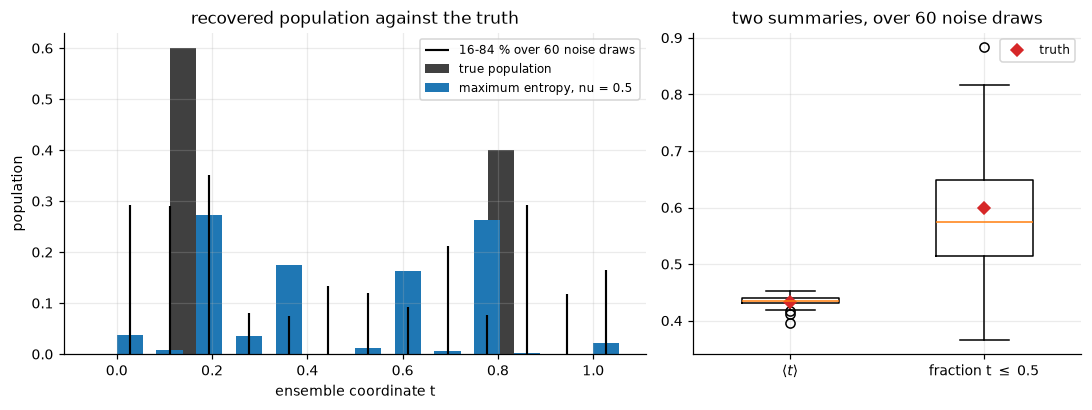

<t>              true 0.433 | recovered 0.435 [0.425, 0.442]
fraction t<=0.5  true 0.600 | recovered 0.575 [0.490, 0.681]
per-member weight at the true major state, over draws: 0.16 +/- 0.19 (true 0.60)
the member carrying the largest weight, over draws: 12 different members out of 13


In [11]:
REPEATS = 60
repeat_weights = np.array([
    maxent_weights(design, design @ w_true + np.random.default_rng(500 + k).normal(0.0, SIGMA_E, len(NETWORK)),
                   SIGMA_E, NU)[0]
    for k in range(REPEATS)])

fig, axes = plt.subplots(1, 2, figsize=(10.0, 3.8),
                         gridspec_kw={"width_ratios": [1.5, 1]})
width = 0.055
axes[0].bar(T_GRID - width / 2, w_true, width, color="0.25", label="true population")
axes[0].bar(T_GRID + width / 2, w_maxent, width, color="C0", label=f"maximum entropy, nu = {NU}")
axes[0].vlines(T_GRID + width / 2, np.percentile(repeat_weights, 16, axis=0),
               np.percentile(repeat_weights, 84, axis=0), color="k", lw=1.4,
               label=f"16-84 % over {REPEATS} noise draws")
axes[0].set_xlabel("ensemble coordinate t")
axes[0].set_ylabel("population")
axes[0].set_title("recovered population against the truth")
axes[0].legend(fontsize=8)

mean_t = repeat_weights @ T_GRID / repeat_weights.sum(1)
closed_fraction = repeat_weights[:, T_GRID <= 0.5].sum(1) / repeat_weights.sum(1)
axes[1].boxplot([mean_t, closed_fraction], tick_labels=[r"$\langle t \rangle$", "fraction t $\\leq$ 0.5"],
                widths=0.5)
axes[1].plot([1, 2], [w_true @ T_GRID, w_true[T_GRID <= 0.5].sum()], "D", color="C3",
             ms=6, label="truth")
axes[1].set_title(f"two summaries, over {REPEATS} noise draws")
axes[1].legend(fontsize=8)
fig.tight_layout()
plt.show()

print(f"<t>              true {w_true @ T_GRID:.3f} | recovered "
      f"{np.percentile(mean_t, 50):.3f} [{np.percentile(mean_t, 16):.3f}, {np.percentile(mean_t, 84):.3f}]")
print(f"fraction t<=0.5  true {w_true[T_GRID <= 0.5].sum():.3f} | recovered "
      f"{np.percentile(closed_fraction, 50):.3f} "
      f"[{np.percentile(closed_fraction, 16):.3f}, {np.percentile(closed_fraction, 84):.3f}]")
print(f"per-member weight at the true major state, over draws: "
      f"{repeat_weights[:, 2].mean():.2f} +/- {repeat_weights[:, 2].std():.2f} (true 0.60)")
print(f"the member carrying the largest weight, over draws: "
      f"{len(set(repeat_weights.argmax(1)))} different members out of {N_MEMBERS}")

## 5. What `nu` does

`nu` buys smoothness with fit quality, and the exchange rate is not linear.
Sweep it and three regimes appear:

* **`nu` too small.** The entropy term is negligible, the solve is a
  non-negative least squares, and the answer is a few spikes wherever the
  noise happened to point. `chi2` stops improving - the data are already
  fitted - but the spikes keep moving from one noise draw to the next. This is
  the regime in which people publish structures that do not exist.
* **`nu` too large.** The answer is the prior. `chi2` climbs and the
  population is flat: you have measured nothing but you cannot be wrong.
* **In between** there is a corner, and the L-curve - `chi2` against entropy -
  is the usual way to find it. Above the corner you pay a lot of fit for a
  little smoothness; below it, a lot of structure for no improvement in fit.

The historic maximum-entropy recipe is stricter: pick the `nu` at which the
reduced chi-square equals 1, on the grounds that fitting better than the noise
is fitting the noise. `MaxEntSpectrum` implements exactly that as its
`target_chisq` setting, searching over `nu` for you.

On this problem the recipe does not help, and the printout below shows why.
The smallest chi-square the ensemble can reach is already below 1 - the
twenty pairs do not over-determine thirteen weights - and chi-square only
climbs back to 1 once `nu` is so large that the population is flat. So the
criterion, applied literally, hands you the prior. It is a good rule when the
data over-determine the answer, which is the normal situation for a
TCSPC decay with thousands of channels, and a misleading one here. Read it as
a diagnostic instead: if `chi2 = 1` is reached only by a flat population, the
data are not asking for structure.

In [12]:
nu_grid = np.geomspace(0.01, 100.0, 24)
sweep = [maxent_weights(design, measured, SIGMA_E, nu) for nu in nu_grid]
sweep_w = np.array([s[0] for s in sweep])
sweep_chi2 = np.array([s[1] for s in sweep])
sweep_entropy = np.array([s[2] for s in sweep])
sweep_converged = np.array([s[3].converged for s in sweep])

nu_chi2_one = float(np.interp(1.0, sweep_chi2, nu_grid)) if sweep_chi2[0] < 1.0 < sweep_chi2[-1] else np.nan
print(f"{'nu':>8} {'chi2/pair':>10} {'entropy':>9} {'<t>':>6} {'max w':>7}  converged  iterations")
for nu, (w, chi2, entropy, sol) in zip(nu_grid, sweep):
    print(f"{nu:8.3g} {chi2:10.3f} {entropy:9.4f} {w @ T_GRID / w.sum():6.3f} {w.max():7.3f}"
          f"{str(sol.converged):>11}  {sol.iterations}")
if np.isfinite(nu_chi2_one):
    w_at_one, _, _, _ = maxent_weights(design, measured, SIGMA_E, nu_chi2_one)
    print(f"\nnu at chi2 per pair = 1 : {nu_chi2_one:.1f}")
    print(f"  its largest weight    : {w_at_one.max():.3f}  "
          f"(a flat population would be {1 / N_MEMBERS:.3f}) - the criterion returns the prior")
else:
    print("\nchi2 per pair never crosses 1 on this grid: the smallest achievable "
          "chi2 is already above 1, so the criterion has no solution at all")

      nu  chi2/pair   entropy    <t>   max w  converged  iterations
    0.01      0.794   -1.2655  0.442   0.365      False  20000
  0.0149      0.794   -1.2654  0.442   0.365      False  20000
  0.0223      0.794   -1.2654  0.442   0.365      False  20000
  0.0332      0.794   -1.2654  0.442   0.365      False  20000
  0.0496      0.794   -1.2653  0.442   0.365      False  20000
  0.0741      0.794   -1.2651  0.442   0.365      False  20000
   0.111      0.794   -1.2645  0.442   0.364      False  20000
   0.165      0.794   -1.2573  0.442   0.362      False  20000
   0.246      0.794   -1.1938  0.442   0.348      False  20000
   0.367      0.795   -1.0149  0.442   0.315       True  14
   0.548      0.799   -0.6909  0.441   0.255       True  15
   0.819      0.807   -0.3238  0.441   0.178       True  15
    1.22      0.817   -0.1263  0.440   0.135       True  15
    1.82      0.824   -0.0540  0.439   0.114       True  5
    2.72      0.830   -0.0308  0.439   0.101       True  4
    4.0

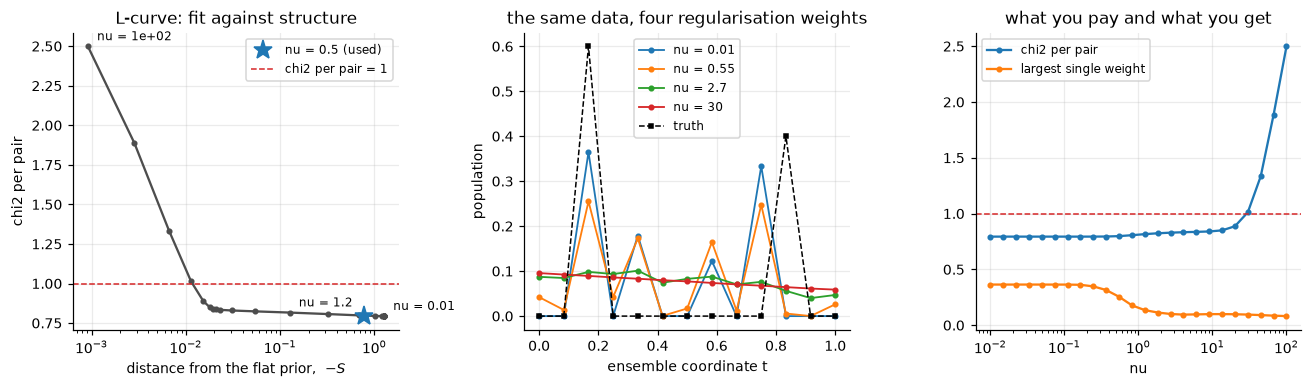

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(12.0, 3.6))

axes[0].plot(-sweep_entropy, sweep_chi2, "-o", ms=3, color="0.3")
for nu, s, c in zip(nu_grid, -sweep_entropy, sweep_chi2):
    if nu in (nu_grid[0], nu_grid[len(nu_grid) // 2], nu_grid[-1]):
        axes[0].annotate(f"nu = {nu:.2g}", (s, c), textcoords="offset points",
                         xytext=(6, 4), fontsize=8)
axes[0].plot(-entropy_maxent, chi2_maxent, "*", ms=13, color="C0", label=f"nu = {NU} (used)")
axes[0].axhline(1.0, color="C3", lw=1, ls="--", label="chi2 per pair = 1")
axes[0].set_xlabel("distance from the flat prior,  $-S$")
axes[0].set_ylabel("chi2 per pair")
axes[0].set_xscale("log")
axes[0].set_title("L-curve: fit against structure")
axes[0].legend(fontsize=8)

for nu in (0.01, 0.5, 3.0, 30.0):
    k = int(np.argmin(np.abs(nu_grid - nu)))
    axes[1].plot(T_GRID, sweep_w[k], marker="o", ms=3, lw=1.2, label=f"nu = {nu_grid[k]:.2g}")
axes[1].plot(T_GRID, w_true, "k--", lw=1, marker="s", ms=3, label="truth")
axes[1].set_xlabel("ensemble coordinate t")
axes[1].set_ylabel("population")
axes[1].set_title("the same data, four regularisation weights")
axes[1].legend(fontsize=8)

axes[2].semilogx(nu_grid, sweep_chi2, "-o", ms=3, color="C0", label="chi2 per pair")
axes[2].semilogx(nu_grid, sweep_w.max(1), "-o", ms=3, color="C1", label="largest single weight")
axes[2].axhline(1.0, color="C3", lw=1, ls="--")
axes[2].set_xlabel("nu")
axes[2].set_title("what you pay and what you get")
axes[2].legend(fontsize=8)
fig.tight_layout()
plt.show()

## 6. What this data set cannot say

Three questions, three honest answers.

**Can the data tell a mixture from a single structure?** Barely, and only
because `sigma` is 0.01. We fit every single member on its own and take the
best; that best single structure sits near the middle of the coordinate - it
is neither state - and its chi-square is a couple of times that of the mixture.
Multiply `sigma` by two and the same comparison collapses: a single
intermediate structure then fits the two-state data acceptably, and nothing in
the data would tell you the molecule exchanges at all. That is the whole
argument for reporting `sigma` honestly.

**Can the data locate the two states?** It can locate their centre of mass. It
cannot locate them individually: we scan every two-member mixture and find a
family of pairs, spread over several members, that fit as well as the true
one. The chi-square surface over that family is almost flat.

**Which structural differences are invisible?** Anything the dyes do not see.
Of the ~250 candidate pairs in a readable efficiency range, dozens change by
less than 0.02 in efficiency across the *entire* open-to-closed transition -
sites near the hinge of the motion, or oriented so that the swing is
perpendicular to the vector between them. We build a second network out of the
twenty weakest of those pairs and run the identical analysis.

The failure is not the one you would expect. That network does **not** return
the flat prior with an obviously bad fit. It returns a confident-looking
population with a perfectly respectable chi-square - and a mean position that
is wrong, and that moves by a third of the coordinate from one noise draw to
the next. Compare the two spreads in the printout: the informative network
pins $\langle t \rangle$ to a few per cent, the blind one to nothing at all.
Neither `chi2` nor the shape of the recovered population tells you which
situation you are in. Only the span of the design matrix does, and that is
computed before any data are taken - which is the argument for designing the
labelling network first and measuring second.

In [14]:
# (a) the best single structure, at the real sigma and at twice it
single_chi2 = np.array([((design[:, k] - measured) ** 2).sum() / SIGMA_E ** 2 / len(NETWORK)
                        for k in range(N_MEMBERS)])
best_single = int(np.argmin(single_chi2))
print(f"best single member          : t = {T_GRID[best_single]:.3f}, chi2 per pair {single_chi2[best_single]:.2f}")
print(f"true two-state mixture      : chi2 per pair {chi2_truth:.2f}")
print(f"maximum-entropy population  : chi2 per pair {chi2_maxent:.2f}")
print(f"  -> the single structure is worse by a factor "
      f"{single_chi2[best_single] / chi2_maxent:.1f}, and it is a structure the sample never visits")
print(f"same comparison at sigma = {2 * SIGMA_E:.3f}: single {single_chi2[best_single] / 4:.2f}"
      f" vs mixture {chi2_truth / 4:.2f}  -> a single structure is no longer rejected")

# (b) every two-member mixture, optimally weighted
two_state = np.full((N_MEMBERS, N_MEMBERS), np.nan)
for i in range(N_MEMBERS):
    for j in range(N_MEMBERS):
        diff = design[:, i] - design[:, j]
        f = np.clip(((measured - design[:, j]) @ diff) / (diff @ diff), 0.0, 1.0) if diff @ diff > 0 else 0.0
        model = f * design[:, i] + (1.0 - f) * design[:, j]
        two_state[i, j] = ((model - measured) ** 2).sum() / SIGMA_E ** 2 / len(NETWORK)
acceptable = np.argwhere(two_state <= two_state.min() + 0.25)
print(f"\ntwo-member mixtures within 0.25 of the best chi2: {len(acceptable)} of {N_MEMBERS ** 2}")
print(f"  their members span t = {T_GRID[acceptable].min():.2f} .. {T_GRID[acceptable].max():.2f}"
      f"  (truth: {T_GRID[2]:.2f} and {T_GRID[10]:.2f})")

# (c) the same analysis on the twenty least sensitive pairs that are still measurable
weak = sorted((efficiency[i, j].max() - efficiency[i, j].min(), i, j)
              for i in range(len(SITES)) for j in range(len(SITES))
              if efficiency[i, j].min() > 0.06 and efficiency[i, j].max() < 0.94)[:20]
blind_design = np.array([efficiency[i, j] for _, i, j in weak])
print(f"\nblind network              : {len(blind_design)} pairs, spans in E "
      f"{blind_design.min(1).min() * 0 + (blind_design.max(1) - blind_design.min(1)).min():.3f}"
      f" .. {(blind_design.max(1) - blind_design.min(1)).max():.3f}  (the noise is {SIGMA_E})")
blind_measured = blind_design @ w_true + np.random.default_rng(99).normal(0.0, SIGMA_E, len(blind_design))
w_blind, chi2_blind, _, _ = maxent_weights(blind_design, blind_measured, SIGMA_E, NU)
print(f"  its answer                : chi2 per pair {chi2_blind:.2f}, largest weight "
      f"{w_blind.max():.3f} at t = {T_GRID[int(np.argmax(w_blind))]:.2f} "
      f"(a flat population would be {1 / N_MEMBERS:.3f} everywhere)")


def mean_t_spread(matrix, sigma, draws=40):
    values = []
    for k in range(draws):
        noise = np.random.default_rng(700 + k).normal(0.0, sigma, matrix.shape[0])
        w, *_ = maxent_weights(matrix, matrix @ w_true + noise, sigma, NU)
        values.append(w @ T_GRID / w.sum())
    return np.percentile(values, [16, 50, 84])


print(f"\n<t> over 40 noise draws            (true {w_true @ T_GRID:.3f})")
for label, matrix in (("informative network", design), ("blind network      ", blind_design)):
    low, mid, high = mean_t_spread(matrix, SIGMA_E)
    print(f"  {label}: {mid:.3f}  [{low:.3f}, {high:.3f}]")

best single member          : t = 0.500, chi2 per pair 2.12
true two-state mixture      : chi2 per pair 0.91
maximum-entropy population  : chi2 per pair 0.80
  -> the single structure is worse by a factor 2.7, and it is a structure the sample never visits
same comparison at sigma = 0.020: single 0.53 vs mixture 0.23  -> a single structure is no longer rejected

two-member mixtures within 0.25 of the best chi2: 48 of 169
  their members span t = 0.00 .. 1.00  (truth: 0.17 and 0.83)

blind network              : 20 pairs, spans in E 0.009 .. 0.019  (the noise is 0.01)
  its answer                : chi2 per pair 0.66, largest weight 0.606 at t = 0.83 (a flat population would be 0.077 everywhere)

<t> over 40 noise draws            (true 0.433)
  informative network: 0.431  [0.424, 0.439]


  blind network      : 0.494  [0.373, 0.662]


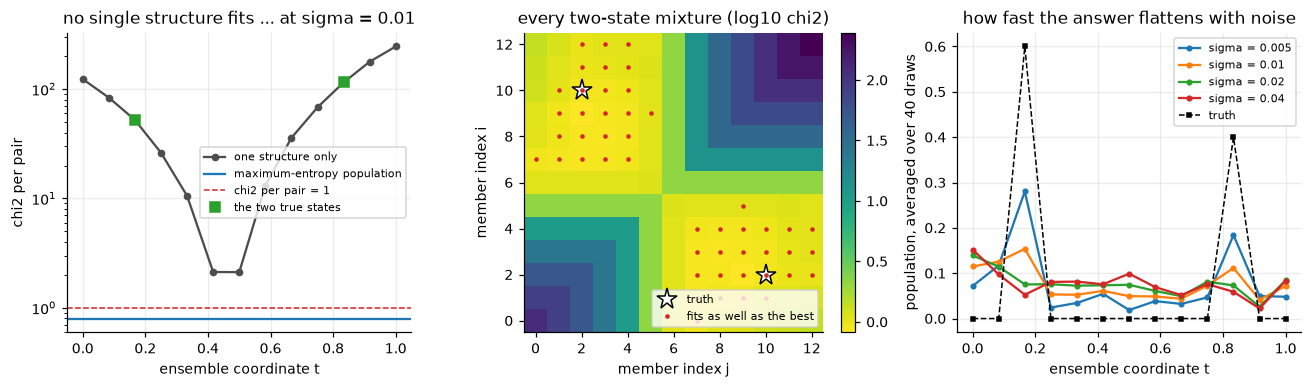

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(12.0, 3.6))

axes[0].plot(T_GRID, single_chi2, "-o", ms=4, color="0.3", label="one structure only")
axes[0].axhline(chi2_maxent, color="C0", lw=1.5, label="maximum-entropy population")
axes[0].axhline(1.0, color="C3", lw=1, ls="--", label="chi2 per pair = 1")
axes[0].plot(T_GRID[w_true > 0], single_chi2[w_true > 0], "s", color="C2", ms=7,
             label="the two true states")
axes[0].set_yscale("log")
axes[0].set_xlabel("ensemble coordinate t")
axes[0].set_ylabel("chi2 per pair")
axes[0].set_title("no single structure fits ... at sigma = 0.01")
axes[0].legend(fontsize=7)

im = axes[1].imshow(np.log10(two_state), origin="lower", cmap="viridis_r",
                    extent=[-0.5, N_MEMBERS - 0.5, -0.5, N_MEMBERS - 0.5])
axes[1].plot([10, 2], [2, 10], "*", color="white", ms=14, mec="k", label="truth")
axes[1].plot(acceptable[:, 1], acceptable[:, 0], ".", color="C3", ms=4,
             label="fits as well as the best")
axes[1].set_xlabel("member index j")
axes[1].set_ylabel("member index i")
axes[1].set_title("every two-state mixture (log10 chi2)")
axes[1].grid(False)
axes[1].legend(fontsize=7, loc="lower right")
fig.colorbar(im, ax=axes[1], fraction=0.046)

for sigma, colour in zip((0.005, 0.01, 0.02, 0.04), ("C0", "C1", "C2", "C3")):
    draws = np.array([
        maxent_weights(design, design @ w_true + np.random.default_rng(700 + k).normal(0.0, sigma, len(NETWORK)),
                       sigma, NU)[0]
        for k in range(40)])
    axes[2].plot(T_GRID, draws.mean(0), "-o", ms=3, color=colour, label=f"sigma = {sigma}")
axes[2].plot(T_GRID, w_true, "k--", marker="s", ms=3, lw=1, label="truth")
axes[2].set_xlabel("ensemble coordinate t")
axes[2].set_ylabel("population, averaged over 40 draws")
axes[2].set_title("how fast the answer flattens with noise")
axes[2].legend(fontsize=7)
fig.tight_layout()
plt.show()

## 7. What to take away

1. **Fit a population, not a structure.** The moment a molecule exchanges, the
   single best-fit structure is a weighted average of things that exist, and
   it need not exist itself. Here the best single structure sits squarely
   between the two states that actually make up the sample.
2. **Maximum entropy is a stated assumption, not the absence of one.** It says
   "closest to the prior among everything that fits". Change the prior and you
   change the answer; the prior is a scientific claim and belongs in the
   methods section next to `nu`.
3. **Report `nu` and how you chose it.** The L-curve corner and the
   `chi2 = 1` criterion do not agree, and neither is automatic. A recovered
   population without its `nu` is not reproducible.
4. **Separate what is resolved from what is drawn.** Moments of the recovered
   population - its mean, the coarse split between two halves of the
   coordinate - survive noise. Individual member weights largely do not. Say
   which one your conclusion rests on.
5. **A good chi-square is not evidence.** The blind network above fits its
   data well and returns a population that looks no worse than the real one,
   while its mean position is wrong and unstable. The span of the design
   matrix - how much each observable moves across the ensemble - is what
   decides whether an answer means anything, and it can be computed before a
   single photon is collected.

Caveats specific to this notebook, so they are not mistaken for results: the
ensemble is a rigid-body interpolation that freezes out roughly 9 A rmsd of
internal conformational change; the accessible volumes are AV1 with generic
linker geometry rather than a calibrated `fps.json`; the measurement is a
single Gaussian-noise draw rather than simulated bursts; and there is no
uncertainty in the forward model at all, whereas in practice the position of a
dye cloud is worth a few Angstrom on its own and would broaden every
conclusion above.

In [16]:
import shutil
shutil.rmtree(ENSEMBLE_DIR, ignore_errors=True)
print("scratch ensemble removed:", ENSEMBLE_DIR)

scratch ensemble removed: /var/folders/cl/txwq_hq52rl_t0f9xjk3g5c00000gn/T/bmra_ensemble_0qqahbap
